In [1]:
import pandas as pd
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

path = "../data/raw/eph/usu_individual_T325.txt"

df = pd.read_csv(path, sep=";")
df.replace(" " * 12, None, inplace=True)
df

,CODUSU,"""ANO4""","""TRIMESTRE""","""NRO_HOGAR""","""COMPONENTE""","""H15""","""REGION""","""MAS_500""","""AGLOMERADO""","""PONDERA""",...,"""V21_03_M""","""V22_01_M""","""V22_02_M""","""V22_03_M""","""P_DECCF""","""P_RDECCF""","""P_GDECCF""","""P_PDECCF""","""P_IDECCF""","""P_ADECCF"""
0,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,8,0,42,"""S""",27,528,...,0,0,0,0,1,1,1,,1,1
1,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,9,0,42,"""S""",27,528,...,0,0,0,0,1,1,1,,1,1
2,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,1,1,42,"""S""",27,528,...,0,0,0,0,1,1,1,,1,1
3,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,2,1,42,"""S""",27,528,...,0,0,0,0,1,1,1,,1,1
4,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,3,1,42,"""S""",27,528,...,0,0,0,0,1,1,1,,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44941,TQRMNOPXUHJOLQCDEHLEH00862602,2025,3,2,5,0,40,"""N""",25,227,...,0,0,0,0,2,2,,2,2,2
44942,TQRMNOQPQHMKLQCDEHLEH00891262,2025,3,1,1,1,40,"""N""",25,336,...,0,0,0,0,7,9,,8,8,10
44943,TQRMNOQPQHMKLQCDEHLEH00891262,2025,3,1,2,1,40,"""N""",25,336,...,0,0,0,0,7,9,,8,8,10
44944,TQRMNOQPQHMKLQCDEHLEH00891262,2025,3,1,3,0,40,"""N""",25,336,...,0,0,0,0,7,9,,8,8,10


In [2]:
print(df.columns)
print(df.dtypes)
print(df.shape)

Index(['CODUSU                       ', ' "ANO4"', ' "TRIMESTRE"',
       ' "NRO_HOGAR"', ' "COMPONENTE"', ' "H15"', ' "REGION"', ' "MAS_500"',
       ' "AGLOMERADO"', ' "PONDERA"',
       ...
       ' "V21_03_M"', ' "V22_01_M"', ' "V22_02_M"', ' "V22_03_M"',
       ' "P_DECCF"', ' "P_RDECCF"', ' "P_GDECCF"', ' "P_PDECCF"',
       ' "P_IDECCF"', ' "P_ADECCF"'],
      dtype='object', length=235)
CODUSU                           object
 "ANO4"                           int64
 "TRIMESTRE"                      int64
 "NRO_HOGAR"                      int64
 "COMPONENTE"                     int64
                                  ...  
 "P_RDECCF"                      object
 "P_GDECCF"                      object
 "P_PDECCF"                      object
 "P_IDECCF"                      object
 "P_ADECCF"                      object
Length: 235, dtype: object
(44946, 235)


In [3]:
PP04B_COD = "PP04B_COD"
PP04D_COD = "PP04D_COD"
for col in df.columns:
	if PP04B_COD in col:
		PP04B_COD = col
		print(f"Found PP04B_COD column: {PP04B_COD}")
	if PP04D_COD in col:
		PP04D_COD = col
		print(f"Found PP04D_COD column: {PP04D_COD}")

Found PP04B_COD column:  "PP04B_COD"
Found PP04D_COD column:  "PP04D_COD"


In [4]:
df[PP04B_COD]

0                None
1                None
2                None
3                4000
4                None
             ...     
44941            None
44942            4000
44943            8600
44944            None
44945            4803
Name:  "PP04B_COD", Length: 44946, dtype: object

In [5]:
df_filtered = df.dropna(subset=[PP04B_COD, PP04D_COD]).copy()
print(df_filtered.shape)

(20066, 235)


PP04B Projection, and Modularity

Bipartite nodes: 656
Bipartite edges: 3279


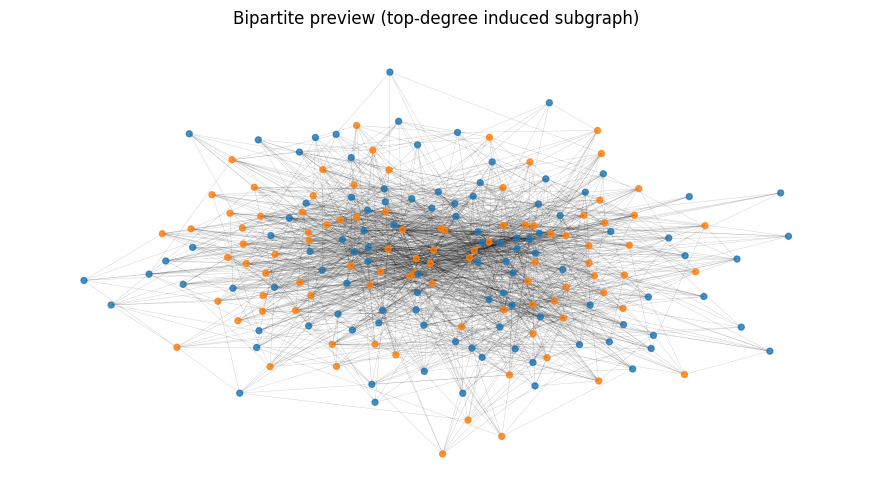

In [6]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

from scripts import gc, comm, pl

# Build a clean edge list from PP04B and PP04D
pairs = df_filtered[[PP04B_COD, PP04D_COD]].copy()
pairs.columns = ["pp04b", "pp04d"]
pairs["pp04b"] = pd.to_numeric(pairs["pp04b"], errors="coerce")
pairs["pp04d"] = pd.to_numeric(pairs["pp04d"], errors="coerce")
pairs = pairs.dropna().astype(int)

if pairs.empty:
	raise ValueError("No valid PP04B/PP04D pairs after numeric cleaning.")

# Disambiguate the second partition so node ids do not overlap
offset = int(pairs["pp04b"].max()) + 1
pairs["pp04d_disamb"] = pairs["pp04d"] + offset

B = gc.build_bipartite_graph(
	pairs,
	caes_id="pp04b",
	ciuo_id="pp04d_disamb",
	logscale=False,
	caes_partition=1,
	ciuo_partition=0,
)

print(f"Bipartite nodes: {B.number_of_nodes()}")
print(f"Bipartite edges: {B.number_of_edges()}")

# Quick visual: top-degree induced subgraph to keep the plot readable
top_n = 200
top_nodes = [n for n, _ in sorted(B.degree(), key=lambda x: x[1], reverse=True)[:top_n]]
B_view = B.subgraph(top_nodes).copy()

pos_b = nx.spring_layout(B_view, seed=45, iterations=1000)
node_colors = [
	"C0" if B_view.nodes[n].get("bipartite") == 1 else "C1" for n in B_view.nodes()
]

plt.figure(figsize=(11, 6))
nx.draw_networkx_nodes(B_view, pos_b, node_size=18, node_color=node_colors, alpha=0.8)
nx.draw_networkx_edges(B_view, pos_b, width=0.3, alpha=0.2)
plt.title("Bipartite preview (top-degree induced subgraph)")
plt.axis("off")
plt.show()

In [19]:
pairs["pp04b"]

3        4000
6        8501
12       9301
13       8401
15       8401
         ... 
44935    5601
44938    8401
44942    4000
44943    8600
44945    4803
Name: pp04b, Length: 20066, dtype: int64

In [20]:
pp04b_unique = sorted(pairs["pp04b"].unique())
pp04d_unique = sorted(pairs["pp04d_disamb"].unique())
print(f"Unique PP04B codes: {pp04b_unique}")
print(f"Unique PP04D codes: {pp04d_unique}")
print(f"Length of unique PP04B codes: {len(pp04b_unique)}")
print(f"Length of unique PP04D codes: {len(pp04d_unique)}")

Unique PP04B codes: [35, 45, 48, 49, 56, 70, 73, 81, 84, 95, 101, 102, 103, 104, 200, 300, 600, 700, 800, 900, 1001, 1002, 1003, 1009, 1100, 1200, 1300, 1400, 1501, 1502, 1600, 1700, 1800, 1902, 2001, 2002, 2009, 2100, 2201, 2202, 2301, 2309, 2400, 2500, 2601, 2602, 2603, 2604, 2701, 2709, 2800, 2900, 3001, 3002, 3003, 3009, 3100, 3200, 3300, 3501, 3502, 3600, 3700, 3800, 3900, 4000, 4501, 4502, 4503, 4504, 4801, 4802, 4803, 4804, 4805, 4806, 4807, 4808, 4810, 4811, 4901, 4902, 4903, 4904, 4909, 5000, 5100, 5201, 5202, 5300, 5500, 5601, 5602, 5800, 5900, 6000, 6100, 6200, 6300, 6400, 6500, 6600, 6800, 6900, 7000, 7100, 7200, 7301, 7302, 7400, 7500, 7701, 7702, 7800, 7900, 8000, 8101, 8102, 8200, 8401, 8402, 8501, 8509, 8600, 8700, 8800, 9000, 9100, 9200, 9301, 9302, 9401, 9402, 9409, 9501, 9502, 9503, 9601, 9602, 9603, 9609, 9700, 9900, 9999]
Unique PP04D codes: [10001, 12001, 13001, 14001, 15001, 15002, 16001, 17001, 20112, 20113, 20121, 20122, 20123, 20131, 20132, 20133, 20201, 20202

In [8]:
print(set(pairs["pp04b"]).intersection(set(pairs["pp04d"])))
print(set(pairs["pp04b"]).intersection(set(pairs["pp04d_disamb"])))

{3001, 2001}
set()


Projection nodes (alpha=0.0046): 144
Projection edges (alpha=0.0046): 271
Original graph had 135 nodes; largest component has 135 nodes.


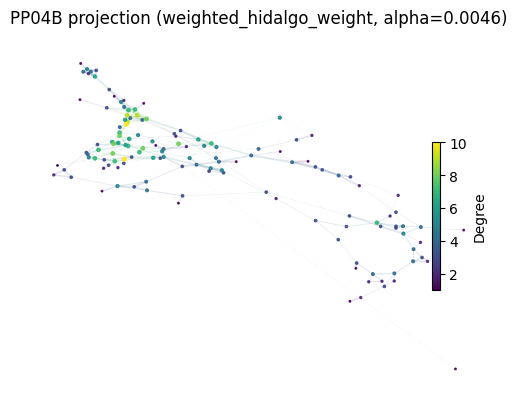

In [25]:
# PP04B projection with weighted Hidalgo weights
P_pp04b = gc.generic_weighted_projected_graph(
	B,
	target_partition=1,
	weight_function=gc.weighted_hidalgo_weight,
)

alpha = 0.0046
P_pp04b_048 = gc.disparity_filter_backbone(P_pp04b, alpha=alpha)

print(f"Projection nodes (alpha={alpha}): {P_pp04b_048.number_of_nodes()}")
print(f"Projection edges (alpha={alpha}): {P_pp04b_048.number_of_edges()}")

if P_pp04b_048.number_of_nodes() == 0:
	raise ValueError("Projection is empty after filtering. Try a higher alpha.")

pos_048 = gc.get_projection_positions(P_pp04b_048, seed=45, method="energy", spring_layout_iterations=50)
degrees_048 = dict(P_pp04b_048.degree())

P_pp04b_048_aux = max(
	nx.connected_components(P_pp04b_048), key=len
)  # Largest connected component
pl.plot_projection_gradient(
	P_pp04b_048,
	pos=pos_048,
	node_values=degrees_048,
	title=f"PP04B projection (weighted_hidalgo_weight, alpha={alpha})",
	colorbar_label="Degree",
	cmap="viridis",
	save=False,
	node_size_map=degrees_048,
	factor_node_size=1.2,
	node_size_exponent=0.8,
	edge_alpha=0.15,
	node_alpha=0.85,
)

Best Louvain modularity: 0.7862
Best resolution: 0.9083
Detected communities: 18


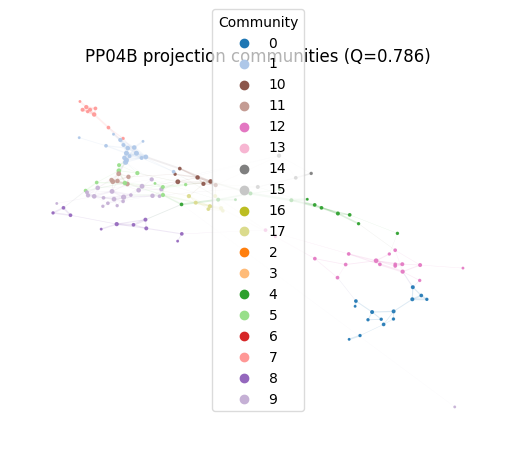

In [26]:
# Louvain communities + modularity on the filtered PP04B projection
partition, modularity_score, best_resolution = comm.best_louvain_partition_random(
	P_pp04b_048,
	seed=45,
	n_samples=25,
	min_resolution=0.5,
	max_resolution=3.0,
)

print(f"Best Louvain modularity: {modularity_score:.4f}")
print(f"Best resolution: {best_resolution:.4f}")
print(f"Detected communities: {len(set(partition.values()))}")

community_ids = sorted(set(partition.values()))
cmap = plt.colormaps["tab20"]
group_color_map = {comm_id: cmap(i % 20) for i, comm_id in enumerate(community_ids)}

pl.plot_projection_by_group(
	P_pp04b_048,
	group_map=partition,
	group_color_map=group_color_map,
	title=f"PP04B projection communities (Q={modularity_score:.3f})",
	legend_title="Community",
	save=False,
	pos=pos_048,
	node_size_map=degrees_048,
	factor_node_size=1.2,
	node_size_exponent=0.8,
	edge_alpha=0.15,
	node_alpha=0.85,
)

nx.write_gexf(P_pp04b_048, "../data/graphs/pp04b_projection_048.gexf")

Alpha=0.0000: Largest CC size=11
Alpha=0.0000: Modularity=0.8793, Communities=108
Alpha=0.0000: Largest CC size=11
Alpha=0.0000: Modularity=0.8829, Communities=106
Alpha=0.0000: Largest CC size=11
Alpha=0.0000: Modularity=0.8925, Communities=103
Alpha=0.0000: Largest CC size=11
Alpha=0.0000: Modularity=0.8717, Communities=101
Alpha=0.0000: Largest CC size=11
Alpha=0.0000: Modularity=0.8810, Communities=98
Alpha=0.0000: Largest CC size=11
Alpha=0.0000: Modularity=0.8810, Communities=98
Alpha=0.0000: Largest CC size=21
Alpha=0.0000: Modularity=0.8742, Communities=98
Alpha=0.0001: Largest CC size=21
Alpha=0.0001: Modularity=0.8680, Communities=98
Alpha=0.0001: Largest CC size=24
Alpha=0.0001: Modularity=0.8660, Communities=96
Alpha=0.0001: Largest CC size=25
Alpha=0.0001: Modularity=0.8613, Communities=95
Alpha=0.0001: Largest CC size=40
Alpha=0.0001: Modularity=0.8553, Communities=93
Alpha=0.0001: Largest CC size=40
Alpha=0.0001: Modularity=0.8699, Communities=89
Alpha=0.0002: Largest CC

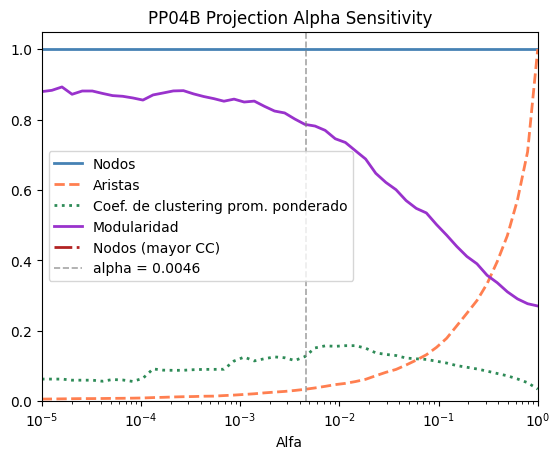

In [28]:
import numpy as np
# Alpha Sensitivity Analysis for PP04B Projection
alpha_values = np.logspace(-5, 0, num=50)
nodes_with_edges_list = []
edge_counts_list = []
clustering_coeffs_list = []
modularity_scores_list = []
nodes_largest_cc_list = []

# Get the total number of edges in the unfiltered projection
total_edges = P_pp04b.number_of_edges()

for alpha in alpha_values:
	P_temp = gc.disparity_filter_backbone(P_pp04b, alpha=alpha)
	
	# Fraction of nodes with at least one edge
	nodes_with_edges = P_temp.number_of_nodes() / P_pp04b.number_of_nodes() if P_pp04b.number_of_nodes() > 0 else 0
	nodes_with_edges_list.append(nodes_with_edges)
	
	# Fraction of edges retained
	edge_fraction = P_temp.number_of_edges() / total_edges if total_edges > 0 else 0
	edge_counts_list.append(edge_fraction)
		
	# Number of nodes in the largest connected component
	if P_temp.number_of_nodes() > 0:
		largest_cc = max(nx.connected_components(P_temp), key=len)
		nodes_largest_cc = len(largest_cc)
		print(f"Alpha={alpha:.4f}: Largest CC size={nodes_largest_cc}")
	else:
		nodes_largest_cc = 0
	nodes_largest_cc_list.append(nodes_largest_cc)

	# Average clustering coefficient
	if P_temp.number_of_nodes() > 0:
		clustering_coeff = nx.average_clustering(P_temp, weight="weight")
	else:
		clustering_coeff = 0
	clustering_coeffs_list.append(clustering_coeff)

	partition, modularity_score, best_resolution = comm.best_louvain_partition_random(
		P_temp,
		seed=45,
		n_samples=40,
		min_resolution=0.6,
		max_resolution=2.0,
	)
	print(f"Alpha={alpha:.4f}: Modularity={modularity_score:.4f}, Communities={len(set(partition.values()))}")
	modularity_scores_list.append(modularity_score)


# Convert to numpy arrays
nodes_with_edges = np.array(nodes_with_edges_list)
edge_counts = np.array(edge_counts_list)
clustering_coefficients = np.array(clustering_coeffs_list)
modularity_scores = np.array(modularity_scores_list)
nodes_largest_cc = np.array(nodes_largest_cc_list)

# Plot using pl.plot_alpha_sensitivity
pl.plot_alpha_sensitivity(
	alphas=alpha_values,
	nodes_with_edges=nodes_with_edges,
	edge_counts=edge_counts,
	clustering_coefficients=clustering_coefficients,
	modularities=modularity_scores,
	title="PP04B Projection Alpha Sensitivity",
	output_path=Path("pp04b_alpha_sensitivity.png"),
	save=False,
	nodes_largest_cc=nodes_largest_cc,
	reference_alpha=0.0046,
)


In [12]:
P_pp04d = gc.generic_weighted_projected_graph(
	B,
	target_partition=0,
	weight_function=gc.weighted_hidalgo_weight,
)

Processing alpha=0.0000 for PP04D projection...
Alpha=0.0000: Largest CC size=96
Alpha=0.0000: Nodes with edges=1.0000, Edge fraction=0.0078, Clustering coeff=0.0825
Alpha=0.0000: Modularity=0.9000, Communities=369
Processing alpha=0.0000 for PP04D projection...
Alpha=0.0000: Largest CC size=96
Alpha=0.0000: Nodes with edges=1.0000, Edge fraction=0.0083, Clustering coeff=0.0926
Alpha=0.0000: Modularity=0.8972, Communities=362
Processing alpha=0.0000 for PP04D projection...
Alpha=0.0000: Largest CC size=100
Alpha=0.0000: Nodes with edges=1.0000, Edge fraction=0.0091, Clustering coeff=0.0986
Alpha=0.0000: Modularity=0.8976, Communities=350
Processing alpha=0.0000 for PP04D projection...
Alpha=0.0000: Largest CC size=104
Alpha=0.0000: Nodes with edges=1.0000, Edge fraction=0.0097, Clustering coeff=0.1047
Alpha=0.0000: Modularity=0.8969, Communities=344
Processing alpha=0.0000 for PP04D projection...
Alpha=0.0000: Largest CC size=106
Alpha=0.0000: Nodes with edges=1.0000, Edge fraction=0.0

ValueError: x and y must have same first dimension, but have shapes (30,) and (60,)

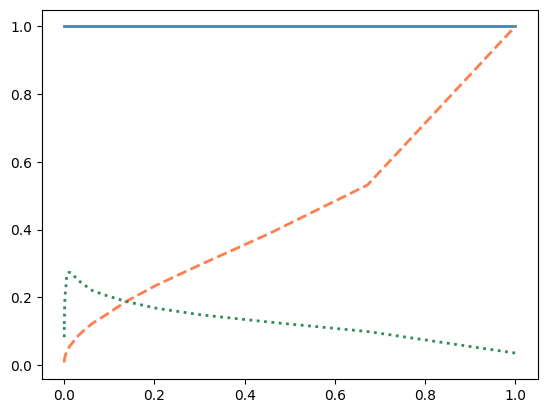

In [ ]:
# Visualize PP04B projections at different alpha values

alpha_values = np.logspace(-5, 0, num=30)
nodes_with_edges_list = []
edge_counts_list = []
clustering_coeffs_list = []
modularity_scores_list = []
nodes_largest_cc_list = []

# Get the total number of edges in the unfiltered projection
total_edges = P_pp04d.number_of_edges()

for alpha in alpha_values:
	print(f"Processing alpha={alpha:.4f} for PP04D projection...")
	P_temp = gc.disparity_filter_backbone(P_pp04d, alpha=alpha)
	
	# Fraction of nodes with at least one edge
	nodes_with_edges = P_temp.number_of_nodes() / P_pp04d.number_of_nodes() if P_pp04d.number_of_nodes() > 0 else 0
	nodes_with_edges_list.append(nodes_with_edges)
	
	# Fraction of edges retained
	edge_fraction = P_temp.number_of_edges() / total_edges if total_edges > 0 else 0
	edge_counts_list.append(edge_fraction)
	
	# Number of nodes in the largest connected component
	if P_temp.number_of_nodes() > 0:
		largest_cc = max(nx.connected_components(P_temp), key=len)
		nodes_largest_cc = len(largest_cc)
		print(f"Alpha={alpha:.4f}: Largest CC size={nodes_largest_cc}")
	else:
		nodes_largest_cc = 0
	nodes_largest_cc_list.append(nodes_largest_cc)
	
	# Average clustering coefficient
	if P_temp.number_of_nodes() > 0:
		clustering_coeff = nx.average_clustering(P_temp, weight="weight")
	else:
		clustering_coeff = 0
	clustering_coeffs_list.append(clustering_coeff)
	print(f"Alpha={alpha:.4f}: Nodes with edges={nodes_with_edges:.4f}, Edge fraction={edge_fraction:.4f}, Clustering coeff={clustering_coeff:.4f}")

	partition, modularity_score, best_resolution = comm.best_louvain_partition_random(
		P_temp,
		seed=45,
		n_samples=40,
		min_resolution=0.6,
		max_resolution=2.0,
	)
	print(f"Alpha={alpha:.4f}: Modularity={modularity_score:.4f}, Communities={len(set(partition.values()))}")
	modularity_scores_list.append(modularity_score)


# Convert to numpy arrays
nodes_with_edges = np.array(nodes_with_edges_list)
edge_counts = np.array(edge_counts_list)
clustering_coefficients = np.array(clustering_coeffs_list)
modularity_scores = np.array(modularity_scores_list)
nodes_largest_cc = np.array(nodes_largest_cc_list)

# Plot using pl.plot_alpha_sensitivity
pl.plot_alpha_sensitivity(
	alphas=alpha_values,
	nodes_with_edges=nodes_with_edges,
	edge_counts=edge_counts,
	clustering_coefficients=clustering_coefficients,
	modularities=modularity_scores,
	title="PP04D Projection Alpha Sensitivity",
	output_path=Path("pp04d_alpha_sensitivity.png"),
	save=False,
	nodes_largest_cc=nodes_largest_cc
)
